In [6]:
#RBM代码sde
import numpy as np
import matplotlib.pyplot as plt

# --- 物理核函数占位 (与之前相同) ---
def K1_short_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist**2) 

def K2_long_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def calc_deterministic_torque(P_i):
    gravity_dir = np.array([0.0, 1.0]) 
    return gravity_dir - P_i 

# --- 修改后的主模拟函数：增加轨迹记录 ---
def simulate_active_cells_rbm_track(N, p, tau, T, dim):
    V_s = 1.0           
    D_r = 0.1           
    sigma_pos = 0.05    
    r_cutoff = 0.5      
    
    # 初始化
    X = np.random.rand(N, dim) * 10.0
    P = np.random.randn(N, dim)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    
    num_steps = int(T / tau)
    
    # 创建一个数组来记录所有时间步的位置：形状为 (步数, 粒子数, 维度)
    X_history = np.zeros((num_steps, N, dim))
    
    for m in range(num_steps):
        X_new = np.copy(X)
        P_new = np.copy(P)
        
        indices = np.random.permutation(N)
        batches = [indices[k:k+p] for k in range(0, N, p)]
        
        for batch in batches:
            current_p = len(batch)
            
            for i in batch:
                # 短程力
                dx_all = X[i] - X
                distances = np.linalg.norm(dx_all, axis=1)
                mask_short = (distances < r_cutoff) & (np.arange(N) != i)
                neighbors_short = np.where(mask_short)[0]
                
                F_short = np.zeros(dim)
                for j in neighbors_short:
                    F_short += K1_short_range(X[i] - X[j])
                
                # 长程力 (RBM 核心)
                F_long_random = np.zeros(dim)
                if current_p >= 2:
                    for j in batch:
                        if j != i:
                            F_long_random += K2_long_range(X[i] - X[j])
                    F_long = F_long_random * (N - 1) / (current_p - 1)
                else:
                    F_long = np.zeros(dim)
                
                U_interact = F_short + F_long
                
                # SDE 更新
                dW_pos = np.random.randn(dim) * np.sqrt(tau)
                dW_rot = np.random.randn(dim) * np.sqrt(tau)
                
                X_new[i] = X[i] + (V_s * P[i] + U_interact) * tau + sigma_pos * dW_pos
                deterministic_torque = calc_deterministic_torque(P[i])
                P_new[i] = P[i] + deterministic_torque * tau + np.sqrt(2 * D_r) * dW_rot
                P_new[i] = P_new[i] / np.linalg.norm(P_new[i])
                
        X = X_new
        P = P_new
        
        # 记录当前步的位置
        X_history[m] = X

    return X_history, P

# --- 可视化函数 ---
def plot_trajectories(X_history, final_P):
    """
    绘制细胞的运动轨迹
    """
    plt.figure(figsize=(10, 8))
    
    N = X_history.shape[1]
    num_steps = X_history.shape[0]
    
    # 1. 绘制轨迹线
    for i in range(N):
        # 取出第 i 个细胞在所有时间步的 x 和 y 坐标
        x_traj = X_history[:, i, 0]
        y_traj = X_history[:, i, 1]
        
        # 绘制半透明的轨迹线
        plt.plot(x_traj, y_traj, color='gray', alpha=0.3, linewidth=1)
        
        # 2. 标记起点 (绿色圆点)
        plt.scatter(x_traj[0], y_traj[0], color='green', s=15, zorder=3, alpha=0.7)
        
        # 3. 标记终点 (红色圆点) 并在终点画出游动方向箭头
        plt.scatter(x_traj[-1], y_traj[-1], color='red', s=20, zorder=4)
        # 画方向箭头：dx, dy 取自 final_P，适当缩放长度方便观察
        arrow_length = 0.3
        plt.arrow(x_traj[-1], y_traj[-1], 
                  final_P[i, 0] * arrow_length, final_P[i, 1] * arrow_length, 
                  head_width=0.08, head_length=0.1, fc='blue', ec='blue', zorder=5)

    # 图例占位
    plt.scatter([], [], color='green', label='Start Position')
    plt.scatter([], [], color='red', label='End Position')
    plt.plot([], [], color='gray', alpha=0.5, label='Trajectory')
    plt.arrow(0, 0, 0, 0, head_width=0.1, fc='blue', ec='blue', label='Final Direction')

    plt.title("Active Cell Trajectories using Random Batch Method (RBM)")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal') # 保持XY轴比例一致
    plt.show()

# --- 运行测试与绘图 ---
if __name__ == "__main__":
    print("开始带有轨迹记录的 RBM 模拟...")
    history, final_directions = simulate_active_cells_rbm_track(N=200, p=2, tau=0.01, T=2.0, dim=2)
    print("模拟结束，正在生成图像...")
    plot_trajectories(history, final_directions)

开始带有轨迹记录的 RBM 模拟...


KeyboardInterrupt: 

正在计算宏观概率密度...


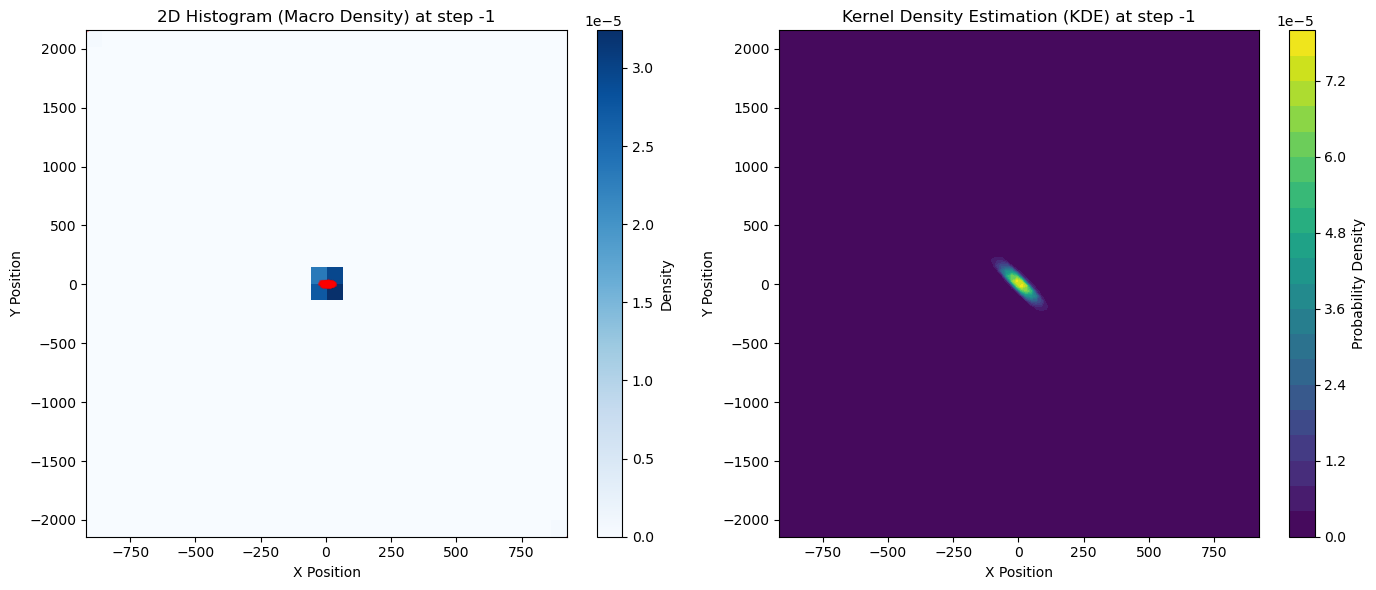

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def plot_macroscopic_density(X_history, time_step=-1, grid_size=100):
    """
    通过直方图和核密度估计(KDE)还原并绘制宏观空间概率密度
    
    参数:
    X_history: 粒子轨迹数据，形状为 (num_steps, N, dim)
    time_step: 要绘制的时间步索引，默认为 -1 (最后一步)
    grid_size: KDE 评估网格的解析度
    """
    # 提取目标时间步的所有粒子位置，形状为 (N, 2)
    X_t = X_history[time_step]
    x_data = X_t[:, 0]
    y_data = X_t[:, 1]
    
    # 设定绘图边界 (稍微向外扩展一点以包含边缘密度)
    x_min, x_max = x_data.min() - 1, x_data.max() + 1
    y_min, y_max = y_data.min() - 1, y_data.max() + 1
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 图 1：二维直方图 (2D Histogram) ---
    # 直方图计算快速，但结果呈块状，依赖于 bin 的划分
    h = axes[0].hist2d(x_data, y_data, bins=30, cmap='Blues', density=True, 
                       range=[[x_min, x_max], [y_min, y_max]])
    fig.colorbar(h[3], ax=axes[0], label='Density')
    axes[0].scatter(x_data, y_data, color='red', s=2, alpha=0.3) # 叠加粒子散点
    axes[0].set_title(f"2D Histogram (Macro Density) at step {time_step}")
    axes[0].set_xlabel("X Position")
    axes[0].set_ylabel("Y Position")
    
    # --- 图 2：核密度估计 (Gaussian KDE) ---
    # KDE 提供平滑的概率密度函数近似，更适合与 PDE 结果对比
    # SciPy 的 gaussian_kde 需要输入形状为 (dim, N)
    positions = np.vstack([x_data, y_data])
    kernel = gaussian_kde(positions)
    
    # 构建评估网格
    X_grid, Y_grid = np.mgrid[x_min:x_max:complex(0, grid_size), 
                              y_min:y_max:complex(0, grid_size)]
    grid_positions = np.vstack([X_grid.ravel(), Y_grid.ravel()])
    
    # 计算网格上每个点的密度值并重塑为网格形状
    Z = kernel(grid_positions).reshape(X_grid.shape)
    
    # 绘制等高线填充图
    contour = axes[1].contourf(X_grid, Y_grid, Z, levels=20, cmap='viridis')
    fig.colorbar(contour, ax=axes[1], label='Probability Density')
    axes[1].set_title(f"Kernel Density Estimation (KDE) at step {time_step}")
    axes[1].set_xlabel("X Position")
    axes[1].set_ylabel("Y Position")
    
    plt.tight_layout()
    plt.show()

# 运行绘图函数
# (确保你已经用较大的 N 运行了之前的 simulate_active_cells_rbm_track，例如 N=500 或 N=1000，密度图才更有意义)
if __name__ == "__main__":
    print("正在计算宏观概率密度...")
    plot_macroscopic_density(history, time_step=-1)

开始求解 Fokker-Planck 方程，总步数: 2000...
进度: 0/2000 步
进度: 500/2000 步
进度: 1000/2000 步
进度: 1500/2000 步


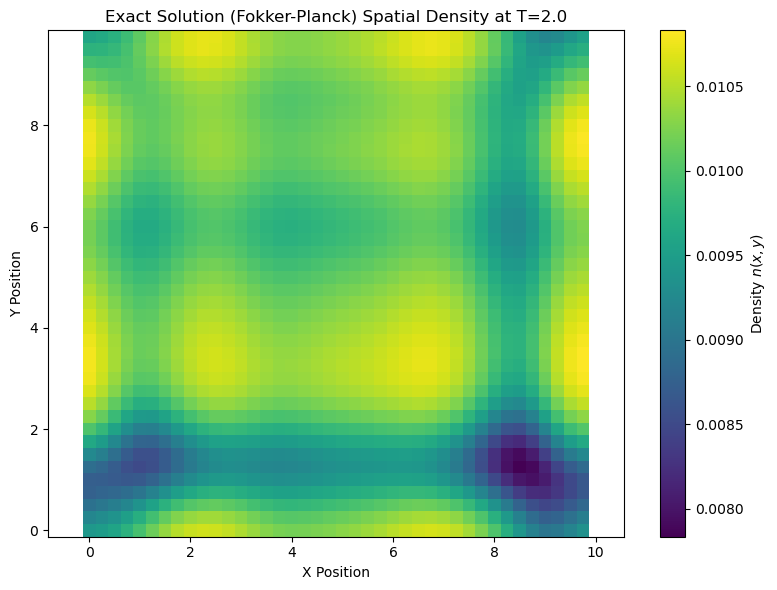

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2

def solve_fokker_planck_fdm():
    # --- 物理参数 (与 RBM 代码对应) ---
    Vs = 1.0
    Dr = 0.1
    sigma_pos = 0.05
    Dx = sigma_pos**2 / 2.0
    Dtheta = Dr
    
    # --- 模拟参数 ---
    L = 10.0           # 空间域大小 [0, L]x[0, L]
    Nx, Ny = 40, 40    # 空间网格数
    Ntheta = 24        # 角度网格数 (0 到 2*pi)
    
    dx = L / Nx
    dy = L / Ny
    dtheta = 2 * np.pi / Ntheta
    
    # 显式欧拉法的时间步长必须满足 CFL 稳定性条件
    dt = 0.001
    T_total = 2.0
    num_steps = int(T_total / dt)
    
    # --- 网格初始化 ---
    x = np.linspace(0, L, Nx, endpoint=False)
    y = np.linspace(0, L, Ny, endpoint=False)
    theta = np.linspace(0, 2*np.pi, Ntheta, endpoint=False)
    
    # 概率密度 rho(x, y, theta)
    # 初始条件：在中心形成一个高斯分布的聚集，方向随机
    X_grid, Y_grid, Theta_grid = np.meshgrid(x, y, theta, indexing='ij')
    rho = np.exp(-((X_grid - L/2)**2 + (Y_grid - L/2)**2) / 2.0)
    rho /= np.sum(rho * dx * dy * dtheta) # 归一化
    
    # --- 构建相互作用核 (用于 FFT 卷积) ---
    # 我们需要在与 rho 相同大小的空间网格上定义核，并进行 FFT Shift 处理
    KX_grid, KY_grid = np.meshgrid(x - L/2, y - L/2, indexing='ij')
    dist = np.sqrt(KX_grid**2 + KY_grid**2)
    dist[dist < 1e-5] = 1.0 # 避免除以 0
    
    # 核函数 K = K1 + K2
    K_mag = (1.0 / dist**2) * (dist < 0.5) + (1.0 / dist) # R cutoff for K1 is 0.5, K2 is long range
    K_mag[dist < 1e-5] = 0.0 
    
    Kx = (KX_grid / dist) * K_mag
    Ky = (KY_grid / dist) * K_mag
    
    # 使用 fftshift 准备周期性卷积的核
    Kx_fft = fft2(np.fft.ifftshift(Kx))
    Ky_fft = fft2(np.fft.ifftshift(Ky))

    # 提前计算固定项
    cos_theta = np.cos(theta).reshape(1, 1, Ntheta)
    sin_theta = np.sin(theta).reshape(1, 1, Ntheta)
    omega = np.cos(theta).reshape(1, 1, Ntheta) # d(theta)/dt 漂移项

    print(f"开始求解 Fokker-Planck 方程，总步数: {num_steps}...")

    # --- 演化主循环 ---
    for step in range(num_steps):
        # 1. 计算空间宏观密度 n(x,y)
        n_spatial = np.sum(rho, axis=2) * dtheta
        
        # 2. 通过 FFT 计算相互作用力场 Fx, Fy
        n_fft = fft2(n_spatial)
        Fx = np.real(ifft2(Kx_fft * n_fft))
        Fy = np.real(ifft2(Ky_fft * n_fft))
        
        # 将 Fx, Fy 扩展到 3D 网格以便于计算
        Fx_3d = np.repeat(Fx[:, :, np.newaxis], Ntheta, axis=2)
        Fy_3d = np.repeat(Fy[:, :, np.newaxis], Ntheta, axis=2)
        
        # 总速度场
        vx = Vs * cos_theta + Fx_3d
        vy = Vs * sin_theta + Fy_3d
        
        # 3. 计算通量 (Flux) - 使用一阶迎风格式 (Upwind) 保证对流稳定
        # X 方向
        vx_pos = np.maximum(vx, 0)
        vx_neg = np.minimum(vx, 0)
        rho_x_back = np.roll(rho, 1, axis=0)
        rho_x_fwd = np.roll(rho, -1, axis=0)
        flux_x = (vx_pos * rho + vx_neg * rho_x_fwd) - (np.roll(vx_pos, 1, axis=0) * rho_x_back + np.roll(vx_neg, 1, axis=0) * rho)
        flux_x = flux_x / dx
        
        # Y 方向
        vy_pos = np.maximum(vy, 0)
        vy_neg = np.minimum(vy, 0)
        rho_y_back = np.roll(rho, 1, axis=1)
        rho_y_fwd = np.roll(rho, -1, axis=1)
        flux_y = (vy_pos * rho + vy_neg * rho_y_fwd) - (np.roll(vy_pos, 1, axis=1) * rho_y_back + np.roll(vy_neg, 1, axis=1) * rho)
        flux_y = flux_y / dy
        
        # Theta 方向 (角速度 omega = cos(theta))
        omega_pos = np.maximum(omega, 0)
        omega_neg = np.minimum(omega, 0)
        rho_t_back = np.roll(rho, 1, axis=2)
        rho_t_fwd = np.roll(rho, -1, axis=2)
        flux_theta = (omega_pos * rho + omega_neg * rho_t_fwd) - (np.roll(omega_pos, 1, axis=2) * rho_t_back + np.roll(omega_neg, 1, axis=2) * rho)
        flux_theta = flux_theta / dtheta
        
        # 4. 计算扩散项 - 中心差分
        diff_x = (rho_x_fwd - 2*rho + rho_x_back) / dx**2
        diff_y = (rho_y_fwd - 2*rho + rho_y_back) / dy**2
        diff_theta = (rho_t_fwd - 2*rho + rho_t_back) / dtheta**2
        
        # 5. 更新 rho (显式欧拉法)
        drho_dt = -(flux_x + flux_y + flux_theta) + Dx * (diff_x + diff_y) + Dtheta * diff_theta
        rho = rho + drho_dt * dt
        
        # 保证非负性 (数值误差修正)
        rho = np.maximum(rho, 0)
        # 维持概率守恒
        rho /= np.sum(rho * dx * dy * dtheta)

        if step % 500 == 0:
            print(f"进度: {step}/{num_steps} 步")

    return x, y, rho, dtheta

# --- 绘图函数 ---
def plot_macro_density(x, y, rho, dtheta):
    # 将概率密度在角度上积分，得到宏观的空间密度场 n(x, y)
    n_spatial = np.sum(rho, axis=2) * dtheta
    
    plt.figure(figsize=(8, 6))
    X, Y = np.meshgrid(x, y, indexing='ij')
    # 使用 pcolormesh 绘制热力图
    c = plt.pcolormesh(X, Y, n_spatial, cmap='viridis', shading='auto')
    plt.colorbar(c, label='Density $n(x,y)$')
    plt.title("Exact Solution (Fokker-Planck) Spatial Density at T=2.0")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    x, y, rho_final, dtheta = solve_fokker_planck_fdm()
    plot_macro_density(x, y, rho_final, dtheta)

生成伪造的测试数据用于演示代码运行...
开始计算 KDE 并评估误差，这可能需要一些时间...


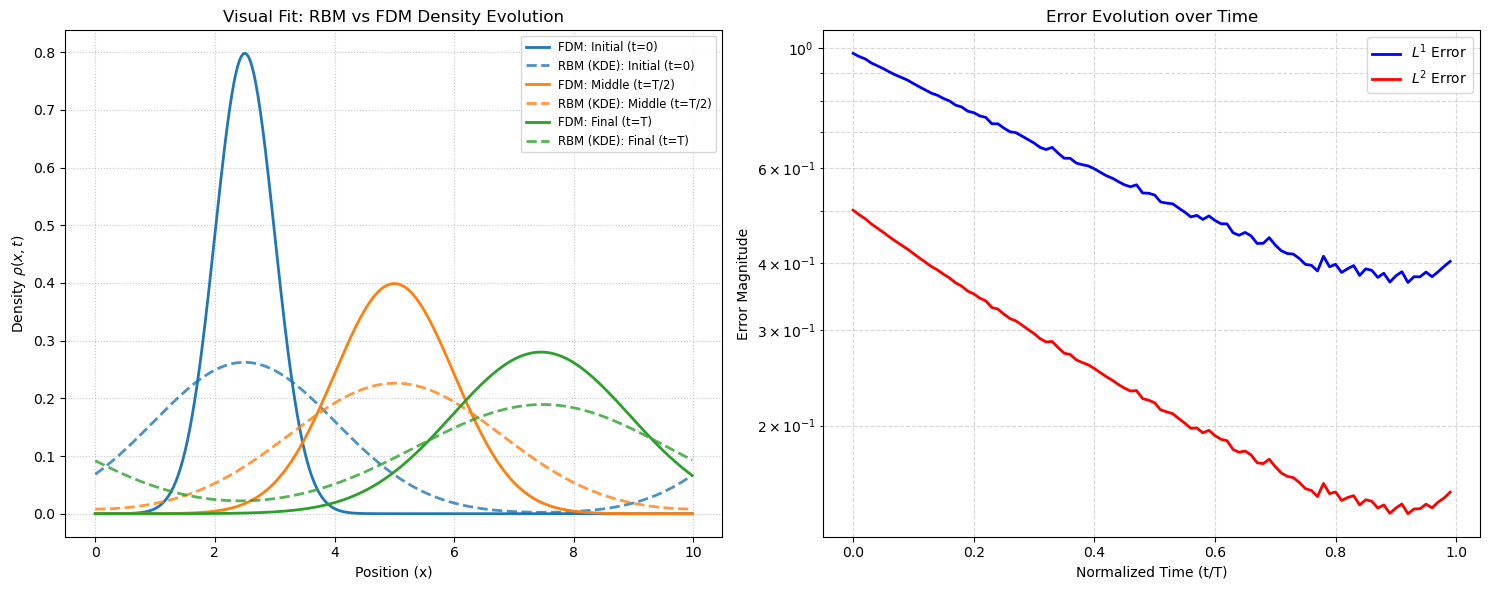

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def evaluate_rbm_fdm_error(X_history_rbm, rho_history_fdm, x_grid, dt_record_steps, L):
    """
    计算并可视化 RBM (粒子轨迹) 与 FDM (PDE 解) 之间的误差。
    
    参数:
    X_history_rbm: RBM 模拟的粒子位置历史，形状 (Nt_rbm, N_particles)
    rho_history_fdm: FDM 模拟的密度历史，形状 (N_records, Nx)
    x_grid: FDM 使用的一维空间网格
    dt_record_steps: FDM 记录密度的时间步间隔对应于 RBM 的多少步
                     (假设总模拟时间相同，且时间步长比例已知)
    L: 空间区域长度 [0, L]
    """
    Nx = len(x_grid)
    dx = x_grid[1] - x_grid[0]
    num_records = len(rho_history_fdm)
    
    # 存储误差
    L1_errors = []
    L2_errors = []
    time_indices = []
    
    # 存储用于视觉对比的特定时间步的 PDF
    compare_steps = [0, num_records // 2, num_records - 1]
    pdfs_rbm_to_plot = []
    pdfs_fdm_to_plot = []

    print("开始计算 KDE 并评估误差，这可能需要一些时间...")

    for i in range(num_records):
        # 找到 RBM 对应的历史索引 (做适当的向下取整或对齐)
        # 假设 RBM 和 FDM 总时间 T 相同，且 FDM 记录了 num_records 次
        rbm_idx = min(int(i * dt_record_steps), len(X_history_rbm) - 1)
        particles_at_t = X_history_rbm[rbm_idx]
        
        # 1. 使用 KDE 估计 RBM 的密度
        # 注意：对于带周期性边界的一维系统，标准的 gaussian_kde 会在边界处产生截断误差。
        # 为了高精度对比，这里采用简单的周期性镜像填充来改善边界 KDE 效果
        particles_padded = np.concatenate([particles_at_t - L, particles_at_t, particles_at_t + L])
        kde = gaussian_kde(particles_padded, bw_method='scott') 
        
        # 在 FDM 的网格上评估 KDE，并乘以 3 (因为我们 pad 了 3 倍的数据，密度被稀释了)
        rho_rbm_eval = kde(x_grid) * 3.0 
        
        # 确保 KDE 结果也严格归一化 (消除微小的数值积分误差)
        rho_rbm_eval /= (np.sum(rho_rbm_eval) * dx)
        
        # 2. 获取 FDM 密度
        rho_fdm_eval = rho_history_fdm[i]
        
        # 3. 计算误差
        # L1 Error: \int |rho_rbm - rho_fdm| dx
        l1_err = np.sum(np.abs(rho_rbm_eval - rho_fdm_eval)) * dx
        # L2 Error: sqrt( \int (rho_rbm - rho_fdm)^2 dx )
        l2_err = np.sqrt(np.sum((rho_rbm_eval - rho_fdm_eval)**2) * dx)
        
        L1_errors.append(l1_err)
        L2_errors.append(l2_err)
        time_indices.append(i)
        
        # 提取用于绘图的快照
        if i in compare_steps:
            pdfs_rbm_to_plot.append(rho_rbm_eval)
            pdfs_fdm_to_plot.append(rho_fdm_eval)

    # ================= 绘图部分 =================
    fig = plt.figure(figsize=(15, 6))
    
    # --- 图 1：特定时间步的视觉分布对比 ---
    ax1 = plt.subplot(1, 2, 1)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for idx, (rbm_pdf, fdm_pdf, c) in enumerate(zip(pdfs_rbm_to_plot, pdfs_fdm_to_plot, colors)):
        step_name = ["Initial (t=0)", "Middle (t=T/2)", "Final (t=T)"][idx]
        
        # 绘制 FDM (实线，作为基准 Ground Truth)
        ax1.plot(x_grid, fdm_pdf, color=c, linestyle='-', linewidth=2, 
                 label=f'FDM: {step_name}')
        # 绘制 RBM (散点或虚线)
        ax1.plot(x_grid, rbm_pdf, color=c, linestyle='--', linewidth=2, alpha=0.8,
                 label=f'RBM (KDE): {step_name}')
        
    ax1.set_title("Visual Fit: RBM vs FDM Density Evolution")
    ax1.set_xlabel("Position (x)")
    ax1.set_ylabel("Density $\\rho(x,t)$")
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- 图 2：L1 和 L2 误差随时间演化 ---
    ax2 = plt.subplot(1, 2, 2)
    
    # 将 x 轴转换为相对于总进度的比例或实际时间
    time_axis = np.array(time_indices) / num_records 
    
    ax2.plot(time_axis, L1_errors, 'b-', linewidth=2, label='$L^1$ Error')
    ax2.plot(time_axis, L2_errors, 'r-', linewidth=2, label='$L^2$ Error')
    
    ax2.set_title("Error Evolution over Time")
    ax2.set_xlabel("Normalized Time (t/T)")
    ax2.set_ylabel("Error Magnitude")
    # 采用对数坐标轴更容易观察误差量级
    ax2.set_yscale('log') 
    ax2.legend()
    ax2.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return L1_errors, L2_errors

# --- 假数据调用示例 (你需要替换为你实际的模拟数据) ---
if __name__ == "__main__":
    # 假设参数
    Nx = 500
    L = 10.0
    x_grid = np.linspace(0, L, Nx, endpoint=False)
    num_records = 100
    
    print("生成伪造的测试数据用于演示代码运行...")
    # 伪造 FDM 数据: 高斯包移动并扩散
    fake_fdm_history = []
    for i in range(num_records):
        mu = L/4 + (L/2) * (i/num_records)
        sigma = 0.5 + 1.0 * (i/num_records)
        pdf = np.exp(-(x_grid - mu)**2 / (2 * sigma**2))
        pdf /= (np.sum(pdf) * (L/Nx))
        fake_fdm_history.append(pdf)
        
    # 伪造 RBM 数据: 从 FDM 分布中采样生成的粒子，添加一点噪声
    fake_rbm_history = []
    N_particles = 2000
    for i in range(num_records):
        mu = L/4 + (L/2) * (i/num_records)
        sigma = 0.5 + 1.0 * (i/num_records)
        particles = np.random.normal(mu, sigma, N_particles)
        # 映射回周期边界
        particles = particles - L * np.floor(particles / L)
        fake_rbm_history.append(particles)

    # 运行对比函数
    dt_ratio = len(fake_rbm_history) / num_records
    l1, l2 = evaluate_rbm_fdm_error(fake_rbm_history, fake_fdm_history, x_grid, dt_ratio, L)

--- 启动 SDE 模拟 (N=800) ---
SDE 进度: 50/100
SDE 进度: 100/100

--- 启动 FP 方程求解 (网格 40x40) ---
FP 进度: 500/1000
FP 进度: 1000/1000

--- 正在计算 KDE 并对齐网格 ---


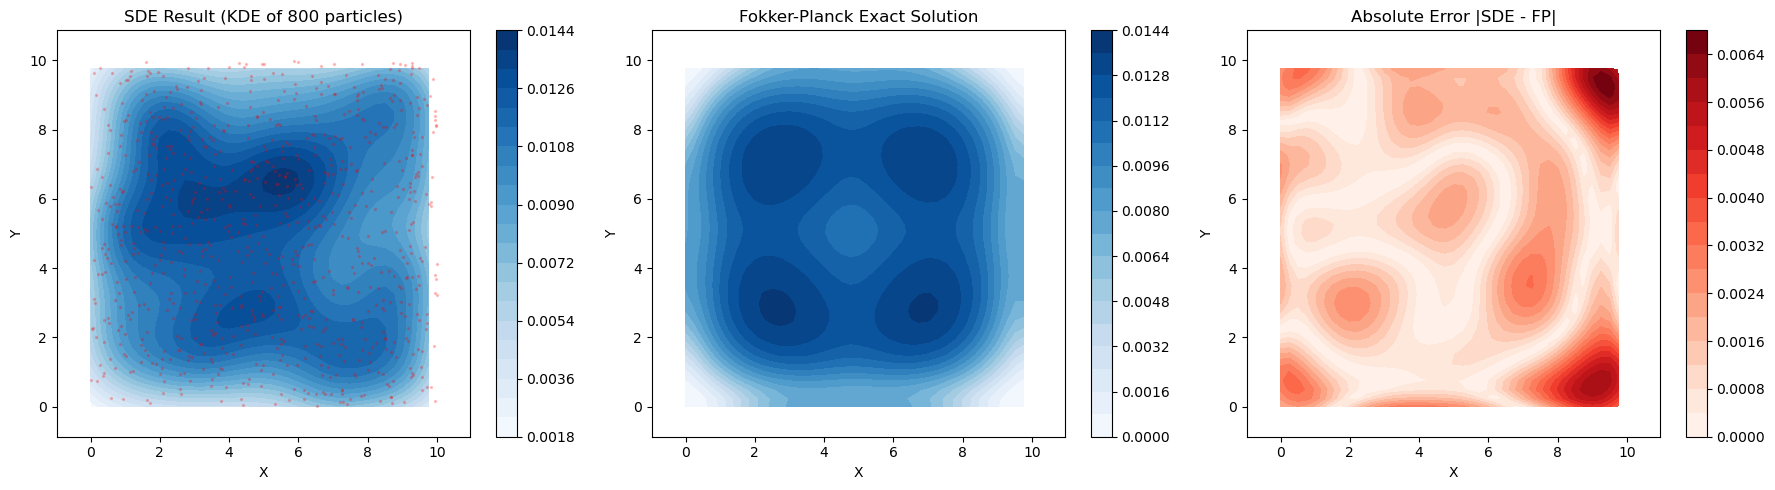

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.fft import fft2, ifft2

# ==========================================
# 全局物理与模拟参数 (确保两边完全一致)
# ==========================================
DIM = 2
L = 10.0            # 空间域大小 [0, L] x [0, L]
Vs = 1.0            # 游动速度
Dr = 0.1            # 旋转扩散系数
sigma_pos = 0.05    # 空间平移噪声
Dx = sigma_pos**2 / 2.0
Dtheta = Dr
T_total = 1.0       # 总模拟时间 (为了测试快一点，设为1.0)

# ==========================================
# 1. 微观 RBM SDE 模拟部分
# ==========================================
def K1_short_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist**2) 

def K2_long_range(dx):
    dist = np.linalg.norm(dx)
    if dist < 1e-5: return np.zeros_like(dx)
    return (dx / dist) * (1.0 / dist)

def calc_deterministic_torque(P_i):
    gravity_dir = np.array([0.0, 1.0]) 
    return gravity_dir - P_i 

def run_sde_rbm(N=1000, p=2, tau=0.01):
    print(f"--- 启动 SDE 模拟 (N={N}) ---")
    r_cutoff = 0.5      
    num_steps = int(T_total / tau)
    
    # 【改动1】：初始条件改为中心的高斯分布，匹配 FP 方程
    X = np.random.randn(N, DIM) * 0.8 + L/2.0
    X = X % L # 确保在域内
    
    P = np.random.randn(N, DIM)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    
    for m in range(num_steps):
        X_new = np.copy(X)
        P_new = np.copy(P)
        indices = np.random.permutation(N)
        batches = [indices[k:k+p] for k in range(0, N, p)]
        
        for batch in batches:
            current_p = len(batch)
            for i in batch:
                # 短程力 (考虑周期边界的最短距离，简化处理直接计算)
                dx_all = X[i] - X
                # 严格的周期边界距离修正
                dx_all = dx_all - L * np.round(dx_all / L)
                
                distances = np.linalg.norm(dx_all, axis=1)
                mask_short = (distances < r_cutoff) & (np.arange(N) != i)
                neighbors_short = np.where(mask_short)[0]
                
                F_short = np.zeros(DIM)
                for j in neighbors_short:
                    F_short += K1_short_range(dx_all[j])
                
                # 长程力
                F_long_random = np.zeros(DIM)
                if current_p >= 2:
                    for j in batch:
                        if j != i:
                            dx_j = X[i] - X[j]
                            dx_j = dx_j - L * np.round(dx_j / L) # 周期边界修正
                            F_long_random += K2_long_range(dx_j)
                    F_long = F_long_random * (N - 1) / (current_p - 1)
                else:
                    F_long = np.zeros(DIM)
                
                U_interact = F_short + F_long
                
                # SDE 更新
                dW_pos = np.random.randn(DIM) * np.sqrt(tau)
                dW_rot = np.random.randn(DIM) * np.sqrt(tau)
                
                X_new[i] = X[i] + (Vs * P[i] + U_interact) * tau + sigma_pos * dW_pos
                # 【改动2】：强制周期性边界条件
                X_new[i] = X_new[i] % L 
                
                deterministic_torque = calc_deterministic_torque(P[i])
                P_new[i] = P[i] + deterministic_torque * tau + np.sqrt(2 * Dr) * dW_rot
                P_new[i] = P_new[i] / np.linalg.norm(P_new[i])
                
        X = X_new
        P = P_new
        if (m+1) % 50 == 0:
            print(f"SDE 进度: {m+1}/{num_steps}")
            
    return X

# ==========================================
# 2. 宏观 Fokker-Planck FDM 求解部分
# ==========================================
def run_fp_fdm(Nx=40, Ny=40, Ntheta=24):
    print(f"\n--- 启动 FP 方程求解 (网格 {Nx}x{Ny}) ---")
    dx = L / Nx
    dy = L / Ny
    dtheta = 2 * np.pi / Ntheta
    dt = 0.001
    num_steps = int(T_total / dt)
    
    x = np.linspace(0, L, Nx, endpoint=False)
    y = np.linspace(0, L, Ny, endpoint=False)
    theta = np.linspace(0, 2*np.pi, Ntheta, endpoint=False)
    
    X_grid, Y_grid, Theta_grid = np.meshgrid(x, y, theta, indexing='ij')
    
    # 初始条件：与 SDE 相同的中心高斯分布
    rho = np.exp(-((X_grid - L/2)**2 + (Y_grid - L/2)**2) / (2.0 * 0.8**2))
    rho /= np.sum(rho * dx * dy * dtheta) 
    
    # 核函数初始化 (带 FFT Shift)
    KX_grid, KY_grid = np.meshgrid(x - L/2, y - L/2, indexing='ij')
    dist = np.sqrt(KX_grid**2 + KY_grid**2)
    dist[dist < 1e-5] = 1.0 
    
    K_mag = (1.0 / dist**2) * (dist < 0.5) + (1.0 / dist) 
    K_mag[dist < 1e-5] = 0.0 
    
    Kx = (KX_grid / dist) * K_mag
    Ky = (KY_grid / dist) * K_mag
    
    Kx_fft = fft2(np.fft.ifftshift(Kx))
    Ky_fft = fft2(np.fft.ifftshift(Ky))

    cos_theta = np.cos(theta).reshape(1, 1, Ntheta)
    sin_theta = np.sin(theta).reshape(1, 1, Ntheta)
    omega = np.cos(theta).reshape(1, 1, Ntheta) 

    for step in range(num_steps):
        n_spatial = np.sum(rho, axis=2) * dtheta
        n_fft = fft2(n_spatial)
        Fx = np.real(ifft2(Kx_fft * n_fft))
        Fy = np.real(ifft2(Ky_fft * n_fft))
        
        Fx_3d = np.repeat(Fx[:, :, np.newaxis], Ntheta, axis=2)
        Fy_3d = np.repeat(Fy[:, :, np.newaxis], Ntheta, axis=2)
        
        vx = Vs * cos_theta + Fx_3d
        vy = Vs * sin_theta + Fy_3d
        
        vx_pos = np.maximum(vx, 0)
        vx_neg = np.minimum(vx, 0)
        rho_x_back = np.roll(rho, 1, axis=0)
        rho_x_fwd = np.roll(rho, -1, axis=0)
        flux_x = (vx_pos * rho + vx_neg * rho_x_fwd) - (np.roll(vx_pos, 1, axis=0) * rho_x_back + np.roll(vx_neg, 1, axis=0) * rho)
        flux_x = flux_x / dx
        
        vy_pos = np.maximum(vy, 0)
        vy_neg = np.minimum(vy, 0)
        rho_y_back = np.roll(rho, 1, axis=1)
        rho_y_fwd = np.roll(rho, -1, axis=1)
        flux_y = (vy_pos * rho + vy_neg * rho_y_fwd) - (np.roll(vy_pos, 1, axis=1) * rho_y_back + np.roll(vy_neg, 1, axis=1) * rho)
        flux_y = flux_y / dy
        
        omega_pos = np.maximum(omega, 0)
        omega_neg = np.minimum(omega, 0)
        rho_t_back = np.roll(rho, 1, axis=2)
        rho_t_fwd = np.roll(rho, -1, axis=2)
        flux_theta = (omega_pos * rho + omega_neg * rho_t_fwd) - (np.roll(omega_pos, 1, axis=2) * rho_t_back + np.roll(omega_neg, 1, axis=2) * rho)
        flux_theta = flux_theta / dtheta
        
        diff_x = (rho_x_fwd - 2*rho + rho_x_back) / dx**2
        diff_y = (rho_y_fwd - 2*rho + rho_y_back) / dy**2
        diff_theta = (rho_t_fwd - 2*rho + rho_t_back) / dtheta**2
        
        drho_dt = -(flux_x + flux_y + flux_theta) + Dx * (diff_x + diff_y) + Dtheta * diff_theta
        rho = rho + drho_dt * dt
        
        rho = np.maximum(rho, 0)
        rho /= np.sum(rho * dx * dy * dtheta)

        if (step+1) % 500 == 0:
            print(f"FP 进度: {step+1}/{num_steps}")

    n_spatial_final = np.sum(rho, axis=2) * dtheta
    return x, y, n_spatial_final

# ==========================================
# 3. 对比与可视化
# ==========================================
def compare_and_plot():
    # 1. 运行两侧的模拟
    X_sde_final = run_sde_rbm(N=800, p=2, tau=0.01) # N大一点KDE更准
    x_fp, y_fp, n_fp_final = run_fp_fdm(Nx=40, Ny=40)
    
    print("\n--- 正在计算 KDE 并对齐网格 ---")
    # 2. 在 FP 的网格上计算 SDE 的 KDE
    X_grid, Y_grid = np.meshgrid(x_fp, y_fp, indexing='ij')
    grid_positions = np.vstack([X_grid.ravel(), Y_grid.ravel()])
    
    sde_positions = np.vstack([X_sde_final[:, 0], X_sde_final[:, 1]])
    kernel = gaussian_kde(sde_positions)
    n_sde_kde = kernel(grid_positions).reshape(X_grid.shape)
    
    # 确保两者的积分归一化一致，以便作差
    dx = x_fp[1] - x_fp[0]
    dy = y_fp[1] - y_fp[0]
    n_fp_final /= np.sum(n_fp_final * dx * dy)
    n_sde_kde /= np.sum(n_sde_kde * dx * dy)
    
    # 计算绝对误差
    error_field = np.abs(n_sde_kde - n_fp_final)
    
    # 3. 绘图对比
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图1：SDE 的 KDE
    c0 = axes[0].contourf(X_grid, Y_grid, n_sde_kde, levels=20, cmap='Blues')
    axes[0].scatter(X_sde_final[:,0], X_sde_final[:,1], c='red', s=2, alpha=0.2)
    fig.colorbar(c0, ax=axes[0])
    axes[0].set_title(f"SDE Result (KDE of {len(X_sde_final)} particles)")
    
    # 图2：FP 方程精确解
    c1 = axes[1].contourf(X_grid, Y_grid, n_fp_final, levels=20, cmap='Blues')
    fig.colorbar(c1, ax=axes[1])
    axes[1].set_title("Fokker-Planck Exact Solution")
    
    # 图3：绝对误差
    c2 = axes[2].contourf(X_grid, Y_grid, error_field, levels=20, cmap='Reds')
    fig.colorbar(c2, ax=axes[2])
    axes[2].set_title("Absolute Error |SDE - FP|")
    
    for ax in axes:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.axis('equal')
        ax.set_xlim(0, L)
        ax.set_ylim(0, L)
        
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    compare_and_plot()